Episode 1 | Reward: 9379.78 | Final Value: 19379.78 | Epsilon: 0.9950
Episode 2 | Reward: 9055.57 | Final Value: 19055.57 | Epsilon: 0.9900
Episode 3 | Reward: 9147.64 | Final Value: 19147.64 | Epsilon: 0.9851
Episode 4 | Reward: 12815.74 | Final Value: 22815.74 | Epsilon: 0.9801
Episode 5 | Reward: 9178.18 | Final Value: 19178.18 | Epsilon: 0.9752
Episode 6 | Reward: 11346.41 | Final Value: 21346.41 | Epsilon: 0.9704
Episode 7 | Reward: 8550.70 | Final Value: 18550.70 | Epsilon: 0.9655
Episode 8 | Reward: 7634.59 | Final Value: 17634.59 | Epsilon: 0.9607
Episode 9 | Reward: 9485.53 | Final Value: 19485.53 | Epsilon: 0.9559
Episode 10 | Reward: 10213.64 | Final Value: 20213.64 | Epsilon: 0.9511
Episode 11 | Reward: 6739.83 | Final Value: 16739.83 | Epsilon: 0.9464
Episode 12 | Reward: 13800.65 | Final Value: 23800.65 | Epsilon: 0.9416
Episode 13 | Reward: 9978.38 | Final Value: 19978.38 | Epsilon: 0.9369
Episode 14 | Reward: 5762.92 | Final Value: 15762.92 | Epsilon: 0.9322
Episode 15 

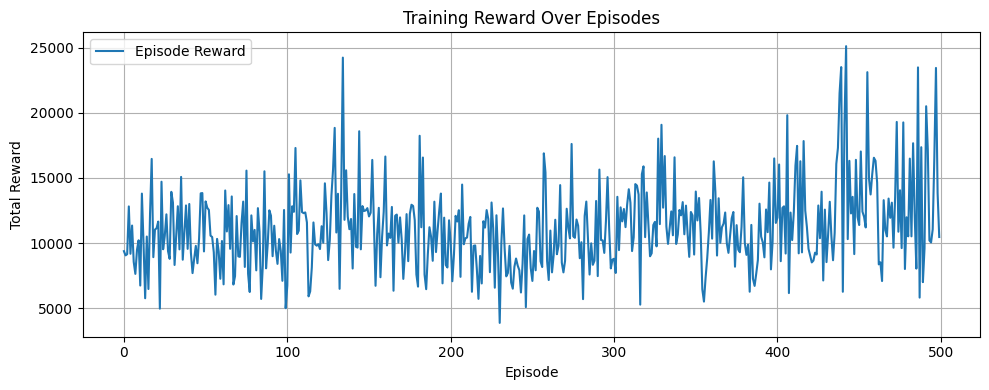

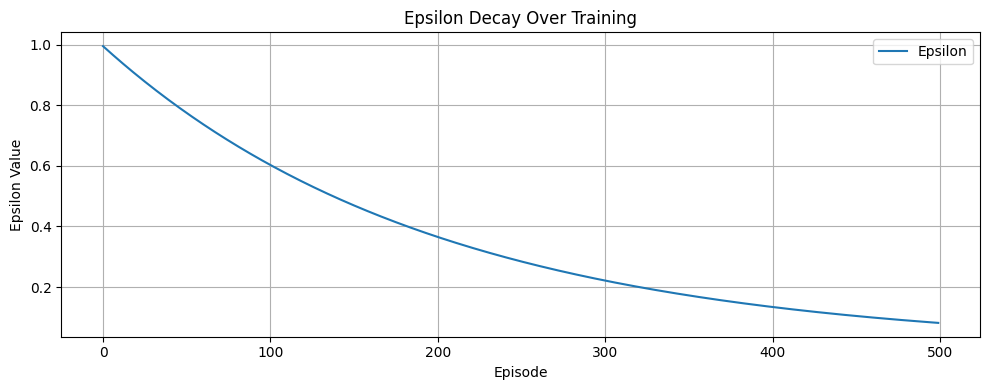

Reward: -8.68, Portfolio Value: 9991.32
Reward: -167.24, Portfolio Value: 9824.08
Reward: -357.03, Portfolio Value: 9467.05
Reward: -84.08, Portfolio Value: 9382.97
Reward: 79.19, Portfolio Value: 9462.16
Reward: 80.00, Portfolio Value: 9542.16
Reward: -391.98, Portfolio Value: 9150.19
Reward: 33.10, Portfolio Value: 9183.28
Reward: -409.70, Portfolio Value: 8773.59
Reward: 63.11, Portfolio Value: 8836.70
Reward: 2.80, Portfolio Value: 8839.50
Reward: 73.03, Portfolio Value: 8912.52
Reward: 267.72, Portfolio Value: 9180.24
Reward: -16.07, Portfolio Value: 9164.17
Reward: 77.28, Portfolio Value: 9241.45
Reward: -192.35, Portfolio Value: 9049.10
Reward: 355.07, Portfolio Value: 9404.17
Reward: -161.15, Portfolio Value: 9243.03
Reward: -85.51, Portfolio Value: 9157.51
Reward: -350.84, Portfolio Value: 8806.68
Reward: -151.32, Portfolio Value: 8655.36
Reward: 30.79, Portfolio Value: 8686.15
Reward: -531.61, Portfolio Value: 8154.55
Reward: -284.01, Portfolio Value: 7870.54
Reward: -6.57, P

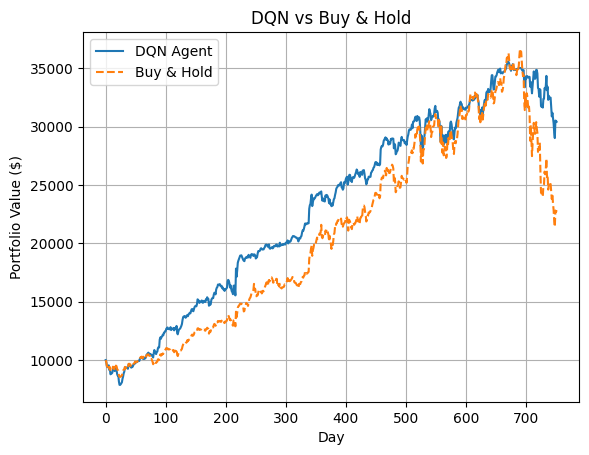

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from datetime import datetime
from multi_stock_env import MultiStockEnv
from dqn_agent import DQNAgent
import os

# --- Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# --- One episode runner ---
def play_one_episode(agent, env, is_train=True):
    state = env.reset()
    total_reward = 0
    done = False
    dqn_returns = []
    prev_val = env.get_portfolio_value()

    while not done:
        action_vector = agent.select_action(state)
        next_state, reward, done, info = env.step(action_vector)

        if is_train:
            agent.store(state, action_vector, reward, next_state, done)
            agent.train()

        state = next_state
        total_reward += reward

        current_val = env.get_portfolio_value()
        dqn_returns.append(current_val - prev_val)
        prev_val = current_val

    if is_train:
        agent.update_epsilon()

    return total_reward, info['cur_val'], dqn_returns

# --- Plot Training Reward ---
def plot_training_rewards(rewards):
    plt.figure(figsize=(10, 4))
    plt.plot(rewards, label='Episode Reward')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Training Reward Over Episodes')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Plot Epsilon Decay ---
def plot_epsilon_decay(epsilon_values):
    plt.figure(figsize=(10, 4))
    plt.plot(epsilon_values, label='Epsilon')
    plt.xlabel('Episode')
    plt.ylabel('Epsilon Value')
    plt.title('Epsilon Decay Over Training')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Training ---
def train_dqn_agent(seed=42):
    set_seed(seed)

    tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
    env = MultiStockEnv(
        symbols=tickers,
        data_dir="stock_data/train_stable",
        reward_type="raw" 
    )

    state_dim = env.state_dim
    num_stocks = len(tickers)
    agent = DQNAgent(state_dim=state_dim, num_stocks=num_stocks)

    episodes = 500  # for now
    rewards_per_episode = []
    epsilon_values = []
    target_update_freq = 10
    all_returns = []

    for ep in range(episodes):
        reward, final_val, episode_returns = play_one_episode(agent, env, is_train=True)

        if ep % target_update_freq == 0:
            agent.update_target_network()

        all_returns.extend(episode_returns)
        rewards_per_episode.append(reward)
        epsilon_values.append(agent.epsilon)
        print(f"Episode {ep+1} | Reward: {reward:.2f} | Final Value: {final_val:.2f} | Epsilon: {agent.epsilon:.4f}")

    # Calculate and print overall Sharpe Ratio
    sharpe = np.mean(all_returns) / (np.std(all_returns) + 1e-6)
    print(f"\nOverall Training Sharpe Ratio: {sharpe:.4f}")

    #  Save trained policy
    os.makedirs("models", exist_ok=True)
    torch.save(agent.policy_net.state_dict(), "models/dqn_trained.pth")
    print(" Trained policy saved to models/dqn_trained.pth")

    plot_training_rewards(rewards_per_episode)
    plot_epsilon_decay(epsilon_values)

    return env, agent, rewards_per_episode

# --- Evaluation ---
def evaluate(agent, env):
    state = env.reset()
    dqn_values = []
    bh_values = []

    init_price = env.stock_prices[0]
    shares = (env.initial_investment / env.num_stocks) / init_price

    done = False
    while not done:
        action_vector = agent.select_action(state)
        state, reward, done, info = env.step(action_vector)
        print(f"Reward: {reward:.2f}, Portfolio Value: {info['cur_val']:.2f}")
        dqn_values.append(env.get_portfolio_value())

        bh_val = np.sum(shares * env.stock_prices[env.cur_step])
        bh_values.append(bh_val)

    plt.plot(dqn_values, label='DQN Agent')
    plt.plot(bh_values, label='Buy & Hold', linestyle='--')
    plt.xlabel('Day')
    plt.ylabel('Portfolio Value ($)')
    plt.title('DQN vs Buy & Hold')
    plt.legend()
    plt.grid()
    plt.show()

# --- Run everything ---
if __name__ == "__main__":
    env, agent, rewards = train_dqn_agent(seed=42)
    evaluate(agent, env)
